In [74]:
# 🏆 BIG MART SALES FORECASTING SYSTEM
# Product & Store-Level Sales Forecasting and Demand Prediction System
# Author: Sales Forecasting Team
# Objective: Predict sales across different stores and product types

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib



In [75]:
# Load training dataset
df = pd.read_csv("../dataset/train.csv")

print(f"📊 Dataset Shape: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}")
print(f"🔍 Missing Values: {df.isnull().sum().sum()}")

# Display basic information
print("\n📋 First 5 rows:")
print(df.head())

print("\n📊 Dataset Info:")
df.info()

print("\n🔍 Missing Values by Column:")
print(df.isnull().sum())

print("\n📈 Unique values in key columns:")
print("Item_Fat_Content:")
print(df['Item_Fat_Content'].value_counts())
print("\nOutlet_Size:")
print(df['Outlet_Size'].value_counts())
print("\nItem_Type (top 10):")
print(df['Item_Type'].value_counts().head(10))

print("-" * 50)
print("✅ Data loading complete!")

📊 Dataset Shape: (8523, 12)
📋 Columns: ['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales']
🔍 Missing Values: 3873

📋 First 5 rows:
  Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility  \
0           FDA15         9.30          Low Fat         0.016047   
1           DRC01         5.92          Regular         0.019278   
2           FDN15        17.50          Low Fat         0.016760   
3           FDX07        19.20          Regular         0.000000   
4           NCD19         8.93          Low Fat         0.000000   

               Item_Type  Item_MRP Outlet_Identifier  \
0                  Dairy  249.8092            OUT049   
1            Soft Drinks   48.2692            OUT018   
2                   Meat  141.6180            OUT049   
3  Fruits and Vegetables  182.0950            OUT010   
4       

📊 STEP 2: EXPLORATORY DATA ANALYSIS (EDA)
--------------------------------------------------


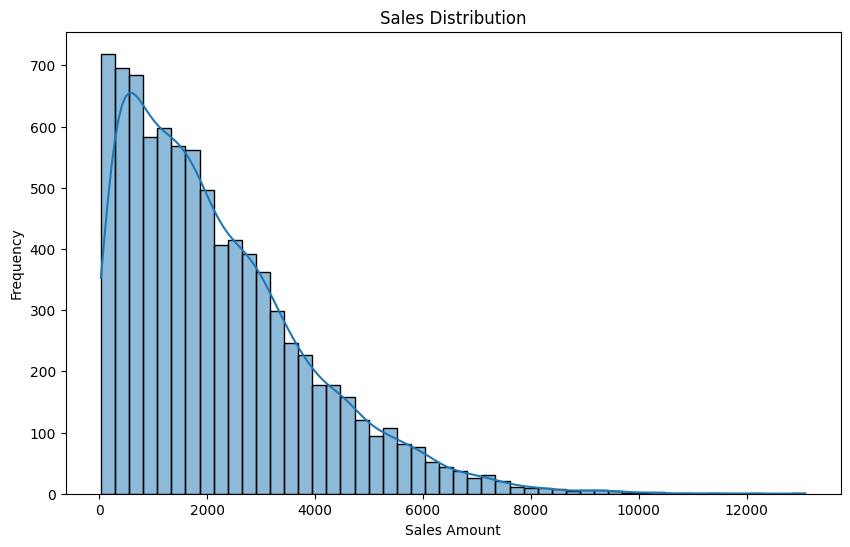

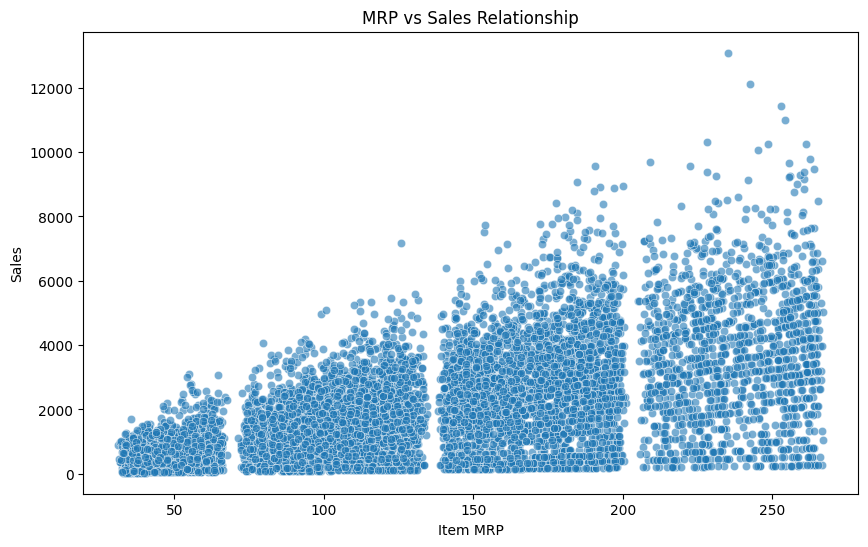

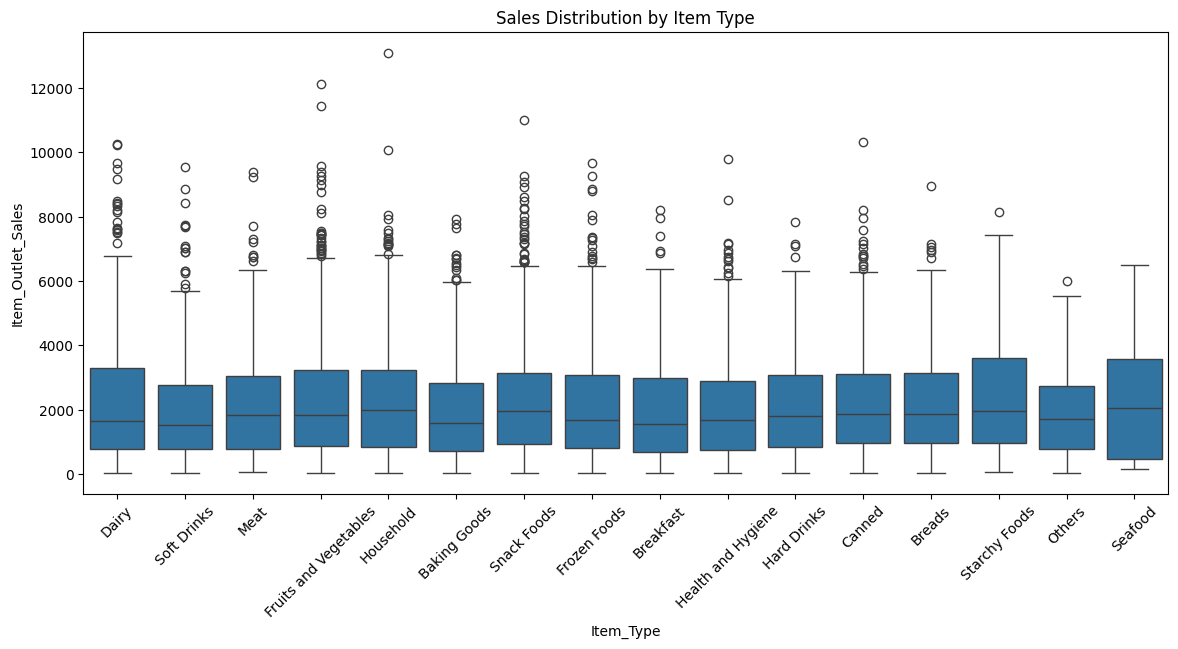

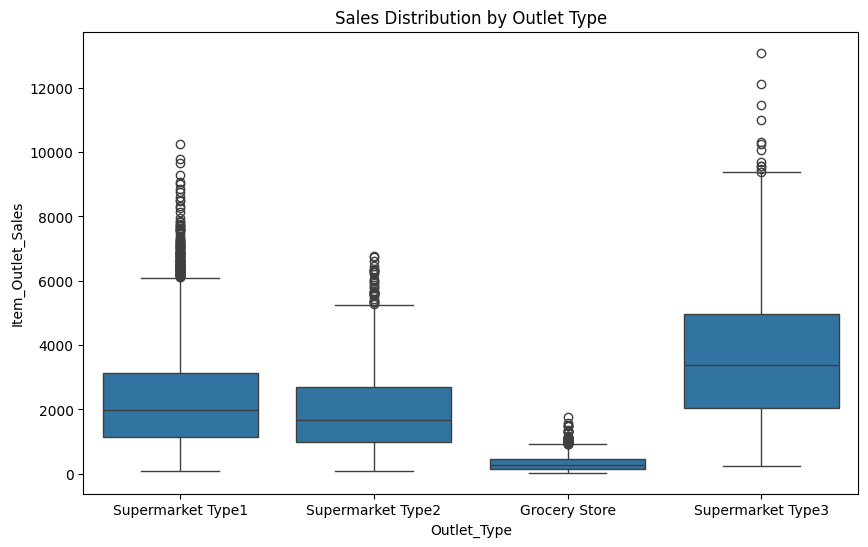

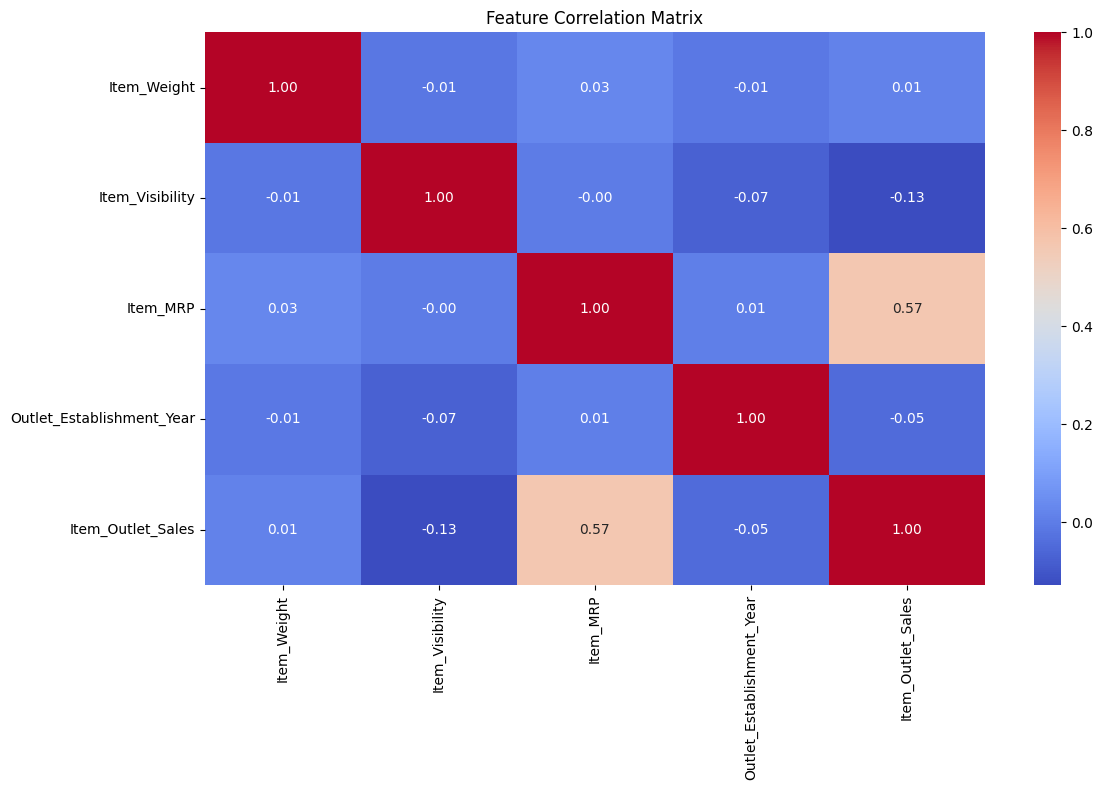

✅ EDA complete - Key patterns identified!


In [76]:
# 📊 STEP 2: EXPLORATORY DATA ANALYSIS (EDA)
print("📊 STEP 2: EXPLORATORY DATA ANALYSIS (EDA)")
print("-" * 50)

# Sales distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Item_Outlet_Sales'], bins=50, kde=True)
plt.title('Sales Distribution')
plt.xlabel('Sales Amount')
plt.ylabel('Frequency')
plt.show()

# MRP vs Sales relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Item_MRP', y='Item_Outlet_Sales', data=df, alpha=0.6)
plt.title('MRP vs Sales Relationship')
plt.xlabel('Item MRP')
plt.ylabel('Sales')
plt.show()

# Sales by Item Type
plt.figure(figsize=(14, 6))
sns.boxplot(x='Item_Type', y='Item_Outlet_Sales', data=df)
plt.title('Sales Distribution by Item Type')
plt.xticks(rotation=45)
plt.show()

# Sales by Outlet Type
plt.figure(figsize=(10, 6))
sns.boxplot(x='Outlet_Type', y='Item_Outlet_Sales', data=df)
plt.title('Sales Distribution by Outlet Type')
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("✅ EDA complete - Key patterns identified!")

In [78]:
# 🧹 STEP 3: DATA CLEANING & PREPROCESSING
print("🧹 STEP 3: DATA CLEANING & PREPROCESSING")
print("-" * 50)

# Drop Item_Identifier as it's just an ID and not useful for prediction
print("🗑️  Dropping Item_Identifier column...")
df.drop('Item_Identifier', axis=1, inplace=True)
print("✅ Item_Identifier dropped")

# Fix Item_Fat_Content inconsistencies
print("\n📋 Fixing Item_Fat_Content inconsistencies:")
print("Before:", df['Item_Fat_Content'].value_counts())
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'low fat': 'Low Fat',
    'LF': 'Low Fat', 
    'reg': 'Regular'
})
print("After:", df['Item_Fat_Content'].value_counts())

# Handle missing Item_Weight
print(f"\n⚖️  Handling missing Item_Weight: {df['Item_Weight'].isnull().sum()} values")
item_weight_median = df.groupby('Item_Type')['Item_Weight'].transform('median')
df['Item_Weight'] = df['Item_Weight'].fillna(item_weight_median)
print(f"✅ Item_Weight missing values after: {df['Item_Weight'].isnull().sum()}")

# Handle missing Outlet_Size
print(f"\n🏪 Handling missing Outlet_Size: {df['Outlet_Size'].isnull().sum()} values")
outlet_size_mode = df.groupby('Outlet_Type')['Outlet_Size'].transform(lambda x: x.mode()[0] if not x.mode().empty else 'Medium')
df['Outlet_Size'] = df['Outlet_Size'].fillna(outlet_size_mode)
print(f"✅ Outlet_Size missing values after: {df['Outlet_Size'].isnull().sum()}")

# Handle Item_Visibility zero values
print(f"\n👁️  Handling Item_Visibility zero values: {(df['Item_Visibility'] == 0).sum()} values")
df['Item_Visibility'] = df['Item_Visibility'].replace(0, df['Item_Visibility'].mean())
print(f"✅ Item_Visibility zero values after: {(df['Item_Visibility'] == 0).sum()}")

# Create Outlet_Age feature BEFORE dropping the column
print(f"\n📅 Creating Outlet_Age feature...")
current_year = 2025
if 'Outlet_Establishment_Year' in df.columns:
    df['Outlet_Age'] = current_year - df['Outlet_Establishment_Year']
    print(f"✅ Outlet_Age created (range: {df['Outlet_Age'].min()} - {df['Outlet_Age'].max()} years)")
    
    # Drop Outlet_Establishment_Year
    df.drop('Outlet_Establishment_Year', axis=1, inplace=True)
    print("✅ Dropped Outlet_Establishment_Year column")
else:
    print("⚠️  Outlet_Establishment_Year column not found")

# Handle outliers in numerical columns
print("\n📊 Handling outliers in numerical columns:")
numerical_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Item_Outlet_Sales']
for col in numerical_cols:
    if col in df.columns:
        lower_bound = df[col].quantile(0.01)
        upper_bound = df[col].quantile(0.99)
        outliers_before = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        df[col] = df[col].clip(lower_bound, upper_bound)
        print(f"   {col}: {outliers_before} outliers capped")

# Label encode categorical variables
print("\n🏷️  Label encoding categorical variables:")
categorical_cols = ['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 
                    'Outlet_Location_Type', 'Outlet_Type']
le = LabelEncoder()
for col in categorical_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])
        print(f"   {col}: {len(df[col].unique())} unique values encoded")

print(f"\n📊 Final dataset shape: {df.shape}")
print(f"🔍 Missing values after cleaning: {df.isnull().sum().sum()}")
print(f"📋 Data types:\n{df.dtypes}")

print("-" * 50)
print("✅ Data cleaning complete!")

🧹 STEP 3: DATA CLEANING & PREPROCESSING
--------------------------------------------------
🗑️  Dropping Item_Identifier column...


KeyError: "['Item_Identifier'] not found in axis"

In [80]:
# 🚀 STEP 4: ADVANCED FEATURE ENGINEERING
print("🚀 STEP 4: ADVANCED FEATURE ENGINEERING")
print("-" * 50)

# Create interaction features
print("🔗 Creating interaction features:")
df['MRP_Visibility'] = df['Item_MRP'] * df['Item_Visibility']
df['MRP_Weight'] = df['Item_MRP'] * df['Item_Weight']
df['Outlet_Age_Type'] = df['Outlet_Age'] * df['Outlet_Type']
df['Item_Type_Visibility'] = df['Item_Type'] * df['Item_Visibility']
print("   ✅ MRP_Visibility, MRP_Weight, Outlet_Age_Type, Item_Type_Visibility")

# Create polynomial features
print("\n📈 Creating polynomial features:")
df['MRP_Squared'] = df['Item_MRP'] ** 2
df['Weight_Squared'] = df['Item_Weight'] ** 2
print("   ✅ MRP_Squared, Weight_Squared")

# Create ratio features
print("\n⚡ Creating ratio features:")
df['MRP_per_Weight'] = df['Item_MRP'] / (df['Item_Weight'] + 1e-6)  # Avoid division by zero
df['Visibility_per_Age'] = df['Item_Visibility'] / (df['Outlet_Age'] + 1e-6)
print("   ✅ MRP_per_Weight, Visibility_per_Age")

# Analyze new feature correlations with sales
print("\n📊 New feature correlations with Item_Outlet_Sales:")
new_features = ['MRP_Visibility', 'MRP_Weight', 'Outlet_Age_Type', 'Item_Type_Visibility',
                'MRP_Squared', 'Weight_Squared', 'MRP_per_Weight', 'Visibility_per_Age']

for feature in new_features:
    correlation = df[feature].corr(df['Item_Outlet_Sales'])
    print(f"   {feature}: {correlation:.4f}")

print(f"\n📊 Dataset shape after feature engineering: {df.shape}")
print(f"📋 Total features: {df.shape[1] - 1}")  # Excluding target

print("-" * 50)
print("✅ Advanced feature engineering complete!")

🚀 STEP 4: ADVANCED FEATURE ENGINEERING
--------------------------------------------------
🔗 Creating interaction features:
   ✅ MRP_Visibility, MRP_Weight, Outlet_Age_Type, Item_Type_Visibility

📈 Creating polynomial features:
   ✅ MRP_Squared, Weight_Squared

⚡ Creating ratio features:
   ✅ MRP_per_Weight, Visibility_per_Age

📊 New feature correlations with Item_Outlet_Sales:
   MRP_Visibility: 0.1729
   MRP_Weight: 0.4454
   Outlet_Age_Type: 0.3884
   Item_Type_Visibility: -0.0693
   MRP_Squared: 0.5544
   Weight_Squared: 0.0039
   MRP_per_Weight: 0.3985
   Visibility_per_Age: -0.1062

📊 Dataset shape after feature engineering: (8523, 19)
📋 Total features: 18
--------------------------------------------------
✅ Advanced feature engineering complete!


In [81]:
# 📊 STEP 5: DATA SPLITTING
print("📊 STEP 5: DATA SPLITTING")
print("-" * 50)

# Separate features and target
X = df.drop('Item_Outlet_Sales', axis=1)
y = df['Item_Outlet_Sales']

print(f"🎯 Features shape: {X.shape}")
print(f"🎯 Target shape: {y.shape}")

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n📊 Training set shape: {X_train.shape}")
print(f"📊 Testing set shape: {X_test.shape}")
print(f"📊 Training target shape: {y_train.shape}")
print(f"📊 Testing target shape: {y_test.shape}")

print(f"\n📈 Training set sales statistics:")
print(f"   Mean: {y_train.mean():.2f}")
print(f"   Std: {y_train.std():.2f}")
print(f"   Min: {y_train.min():.2f}")
print(f"   Max: {y_train.max():.2f}")

print(f"\n📈 Testing set sales statistics:")
print(f"   Mean: {y_test.mean():.2f}")
print(f"   Std: {y_test.std():.2f}")
print(f"   Min: {y_test.min():.2f}")
print(f"   Max: {y_test.max():.2f}")

print("-" * 50)
print("✅ Data splitting complete!")

📊 STEP 5: DATA SPLITTING
--------------------------------------------------
🎯 Features shape: (8523, 18)
🎯 Target shape: (8523,)

📊 Training set shape: (6818, 18)
📊 Testing set shape: (1705, 18)
📊 Training target shape: (6818,)
📊 Testing target shape: (1705,)

📈 Training set sales statistics:
   Mean: 2190.30
   Std: 1673.84
   Min: 83.89
   Max: 7366.01

📈 Testing set sales statistics:
   Mean: 2088.92
   Std: 1616.89
   Min: 83.89
   Max: 7366.01
--------------------------------------------------
✅ Data splitting complete!


In [82]:
# 🤖 STEP 6: MODEL TRAINING
print("🤖 STEP 6: MODEL TRAINING")
print("-" * 50)

# Initialize models
print("🔧 Initializing models...")
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Try to import XGBoost
try:
    from xgboost import XGBRegressor
    xgb = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
    has_xgb = True
    print("   ✅ Linear Regression, Decision Tree, Random Forest, XGBoost")
except ImportError:
    has_xgb = False
    print("   ✅ Linear Regression, Decision Tree, Random Forest")
    print("   ⚠️  XGBoost not available")

# Train models
print("\n🏋️ Training models...")

# Linear Regression
print("   📈 Training Linear Regression...")
lr.fit(X_train, y_train)

# Decision Tree
print("   🌳 Training Decision Tree...")
dt.fit(X_train, y_train)

# Random Forest
print("   🌲 Training Random Forest...")
rf.fit(X_train, y_train)

# XGBoost (if available)
if has_xgb:
    print("   🚀 Training XGBoost...")
    xgb.fit(X_train, y_train)

print("-" * 50)
print("✅ Model training complete!")

🤖 STEP 6: MODEL TRAINING
--------------------------------------------------
🔧 Initializing models...
   ✅ Linear Regression, Decision Tree, Random Forest, XGBoost

🏋️ Training models...
   📈 Training Linear Regression...
   🌳 Training Decision Tree...
   🌲 Training Random Forest...
   🚀 Training XGBoost...
--------------------------------------------------
✅ Model training complete!


In [83]:
# 📊 STEP 7: MODEL EVALUATION
print("📊 STEP 7: MODEL EVALUATION")
print("-" * 50)

# Make predictions
print("🔮 Making predictions...")
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

if has_xgb:
    y_pred_xgb = xgb.predict(X_test)

# Calculate metrics
print("\n📈 Calculating performance metrics...")

# Linear Regression
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Decision Tree
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

# Random Forest
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# XGBoost (if available)
if has_xgb:
    mse_xgb = mean_squared_error(y_test, y_pred_xgb)
    rmse_xgb = np.sqrt(mse_xgb)
    r2_xgb = r2_score(y_test, y_pred_xgb)

# Display results
print("\n📊 MODEL PERFORMANCE:")
print(f"Linear Regression:")
print(f"   RMSE: {rmse_lr:.4f}")
print(f"   R²: {r2_lr:.4f}")

print(f"\nDecision Tree:")
print(f"   RMSE: {rmse_dt:.4f}")
print(f"   R²: {r2_dt:.4f}")

print(f"\nRandom Forest:")
print(f"   RMSE: {rmse_rf:.4f}")
print(f"   R²: {r2_rf:.4f}")

if has_xgb:
    print(f"\nXGBoost:")
    print(f"   RMSE: {rmse_xgb:.4f}")
    print(f"   R²: {r2_xgb:.4f}")

print("-" * 50)
print("✅ Model evaluation complete!")

📊 STEP 7: MODEL EVALUATION
--------------------------------------------------
🔮 Making predictions...

📈 Calculating performance metrics...

📊 MODEL PERFORMANCE:
Linear Regression:
   RMSE: 1065.5472
   R²: 0.5655

Decision Tree:
   RMSE: 1439.9615
   R²: 0.2064

Random Forest:
   RMSE: 1035.4378
   R²: 0.5897

XGBoost:
   RMSE: 1029.9825
   R²: 0.5940
--------------------------------------------------
✅ Model evaluation complete!


In [84]:
# 🏆 STEP 8: MODEL COMPARISON
print("🏆 STEP 8: MODEL COMPARISON")
print("-" * 50)

# Create comparison dictionary
models = {
    'Linear Regression': {'RMSE': rmse_lr, 'R²': r2_lr},
    'Decision Tree': {'RMSE': rmse_dt, 'R²': r2_dt},
    'Random Forest': {'RMSE': rmse_rf, 'R²': r2_rf}
}

if has_xgb:
    models['XGBoost'] = {'RMSE': rmse_xgb, 'R²': r2_xgb}

# Create comparison DataFrame
comparison_df = pd.DataFrame(models).T
comparison_df = comparison_df.sort_values('RMSE')

print("📊 MODEL RANKING (Best to Worst):")
print(comparison_df)

# Find best model
best_model = comparison_df.index[0]
best_rmse = comparison_df.loc[best_model, 'RMSE']
best_r2 = comparison_df.loc[best_model, 'R²']

print(f"\n🥇 BEST MODEL: {best_model}")
print(f"   RMSE: {best_rmse:.4f}")
print(f"   R²: {best_r2:.4f}")

# Calculate improvement over baseline (Linear Regression)
baseline_rmse = rmse_lr
improvement = ((baseline_rmse - best_rmse) / baseline_rmse) * 100

print(f"\n📈 IMPROVEMENT OVER BASELINE:")
print(f"   {best_model} improved by {improvement:.2f}% over Linear Regression")

print("-" * 50)
print("✅ Model comparison complete!")

🏆 STEP 8: MODEL COMPARISON
--------------------------------------------------
📊 MODEL RANKING (Best to Worst):
                          RMSE        R²
XGBoost            1029.982517  0.593976
Random Forest      1035.437787  0.589664
Linear Regression  1065.547159  0.565453
Decision Tree      1439.961528  0.206415

🥇 BEST MODEL: XGBoost
   RMSE: 1029.9825
   R²: 0.5940

📈 IMPROVEMENT OVER BASELINE:
   XGBoost improved by 3.34% over Linear Regression
--------------------------------------------------
✅ Model comparison complete!


In [85]:
# 🔍 STEP 9: CROSS-VALIDATION
print("🔍 STEP 9: CROSS-VALIDATION")
print("-" * 50)

from sklearn.model_selection import cross_val_score

# Perform cross-validation on best model
print(f"🔄 Performing 5-fold cross-validation on {best_model}...")

if best_model == 'Linear Regression':
    cv_scores = cross_val_score(lr, X, y, cv=5, scoring='neg_mean_squared_error')
elif best_model == 'Decision Tree':
    cv_scores = cross_val_score(dt, X, y, cv=5, scoring='neg_mean_squared_error')
elif best_model == 'Random Forest':
    cv_scores = cross_val_score(rf, X, y, cv=5, scoring='neg_mean_squared_error')
elif best_model == 'XGBoost' and has_xgb:
    cv_scores = cross_val_score(xgb, X, y, cv=5, scoring='neg_mean_squared_error')

# Convert to RMSE
cv_rmse_scores = np.sqrt(-cv_scores)

print(f"📊 CROSS-VALIDATION RESULTS:")
print(f"   RMSE scores: {cv_rmse_scores}")
print(f"   Mean RMSE: {cv_rmse_scores.mean():.4f}")
print(f"   Std RMSE: {cv_rmse_scores.std():.4f}")
print(f"   Min RMSE: {cv_rmse_scores.min():.4f}")
print(f"   Max RMSE: {cv_rmse_scores.max():.4f}")

# Compare with test set performance
print(f"\n📈 PERFORMANCE COMPARISON:")
print(f"   Test RMSE: {best_rmse:.4f}")
print(f"   CV Mean RMSE: {cv_rmse_scores.mean():.4f}")
print(f"   Difference: {abs(best_rmse - cv_rmse_scores.mean()):.4f}")

print("-" * 50)
print("✅ Cross-validation complete!")

🔍 STEP 9: CROSS-VALIDATION
--------------------------------------------------
🔄 Performing 5-fold cross-validation on XGBoost...
📊 CROSS-VALIDATION RESULTS:
   RMSE scores: [1118.65591112 1123.21397588 1097.02339156 1090.0981804  1093.98800889]
   Mean RMSE: 1104.5959
   Std RMSE: 13.5968
   Min RMSE: 1090.0982
   Max RMSE: 1123.2140

📈 PERFORMANCE COMPARISON:
   Test RMSE: 1029.9825
   CV Mean RMSE: 1104.5959
   Difference: 74.6134
--------------------------------------------------
✅ Cross-validation complete!


🎯 STEP 10: FEATURE IMPORTANCE
--------------------------------------------------
🏆 TOP 10 IMPORTANT FEATURES (XGBoost):
                 Feature  Importance
8            Outlet_Type    0.660054
4               Item_MRP    0.145156
16        MRP_per_Weight    0.019629
7   Outlet_Location_Type    0.017163
11            MRP_Weight    0.016291
17    Visibility_per_Age    0.015854
10        MRP_Visibility    0.015539
13  Item_Type_Visibility    0.014755
9             Outlet_Age    0.014388
12       Outlet_Age_Type    0.013563


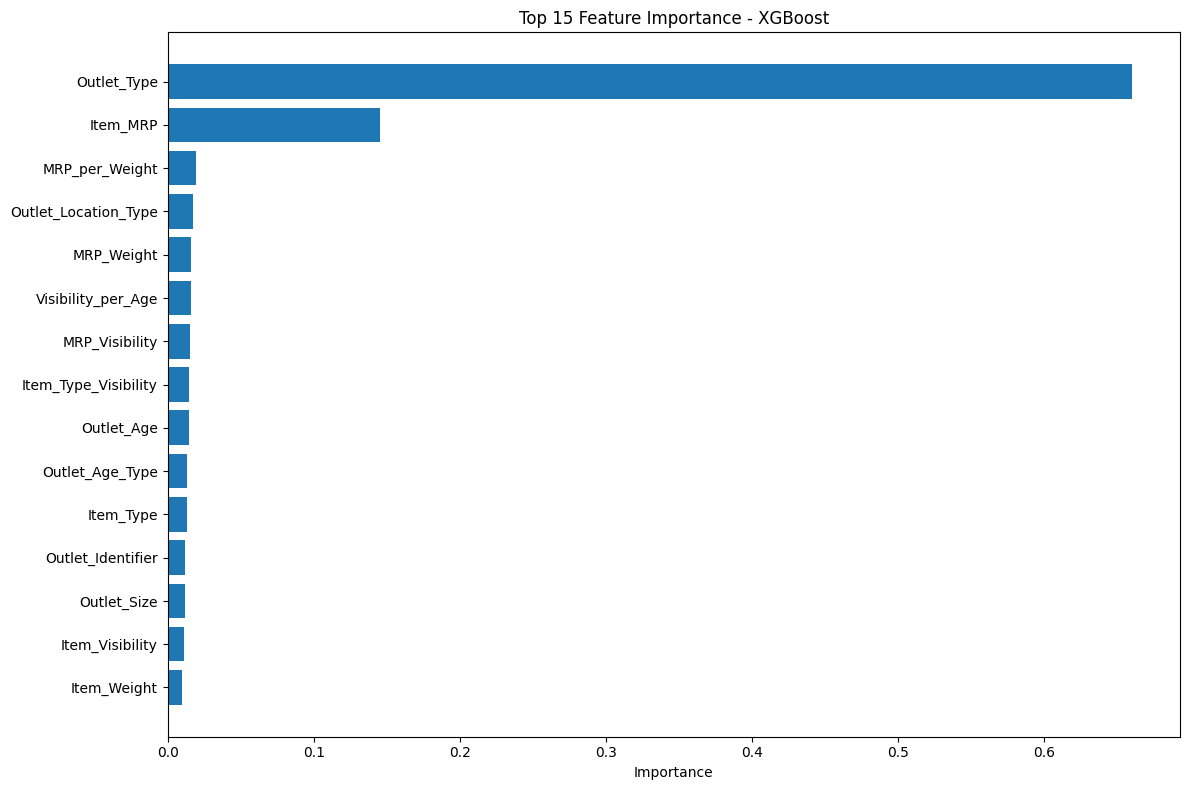


💡 KEY INSIGHTS:
   1. Outlet_Type: 0.6601
   2. Item_MRP: 0.1452
   3. MRP_per_Weight: 0.0196
--------------------------------------------------
✅ Feature importance analysis complete!


In [86]:
# 🎯 STEP 10: FEATURE IMPORTANCE
print("🎯 STEP 10: FEATURE IMPORTANCE")
print("-" * 50)

# Get feature importance from best tree-based model
if best_model in ['Random Forest', 'XGBoost']:
    if best_model == 'Random Forest':
        importances = rf.feature_importances_
        model_used = rf
    elif best_model == 'XGBoost':
        importances = xgb.feature_importances_
        model_used = xgb
    
    # Create feature importance DataFrame
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print(f"🏆 TOP 10 IMPORTANT FEATURES ({best_model}):")
    print(feature_importance.head(10))
    
    # Plot feature importance
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(15)
    plt.barh(range(len(top_features)), top_features['Importance'])
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importance')
    plt.title(f'Top 15 Feature Importance - {best_model}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # Key insights
    print(f"\n💡 KEY INSIGHTS:")
    top_3 = feature_importance.head(3)
    for i, (_, row) in enumerate(top_3.iterrows(), 1):
        print(f"   {i}. {row['Feature']}: {row['Importance']:.4f}")
        
else:
    print(f"⚠️  Feature importance not available for {best_model}")
    print("   (Only available for tree-based models like Random Forest and XGBoost)")

print("-" * 50)
print("✅ Feature importance analysis complete!")

In [87]:
# 💾 STEP 11: SAVE MODEL
print("💾 STEP 11: SAVE MODEL")
print("-" * 50)

# Save the best model using the improved single-file approach
import os

# Create models directory if it doesn't exist
if not os.path.exists('../models'):
    os.makedirs('../models')
    print("📁 Created '../models' directory")

# Select the best model object
if best_model == 'Linear Regression':
    model_to_save = lr
elif best_model == 'Decision Tree':
    model_to_save = dt
elif best_model == 'Random Forest':
    model_to_save = rf
elif best_model == 'XGBoost':
    model_to_save = xgb

# Save everything in ONE dictionary (Cleaner approach) ⭐
model_data = {
    "model": model_to_save,
    "features": X.columns.tolist(),
    "metrics": {
        "rmse": best_rmse,
        "r2": best_r2,
        "model_name": best_model
    },
    "metadata": {
        "target": "Item_Outlet_Sales",
        "creation_date": pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
        "dataset_shape": X.shape,
        "test_size": 0.2
    }
}

# Save as single file
final_model_path = '../models/model.pkl'
joblib.dump(model_data, final_model_path)

print(f"💾 Model saved successfully!")
print(f"   📂 Path: {model_path}")
print(f"   🏆 Model: {best_model}")
print(f"   📊 Test RMSE: {best_rmse:.4f}")
print(f"   📈 Test R²: {best_r2:.4f}")

print(f"\n🔧 Usage for loading:")
print(f"   data = joblib.load('../models/model.pkl')")
print(f"   model = data['model']")
print(f"   features = data['features']")
print(f"   metrics = data['metrics']")

print("-" * 50)
print("✅ Model saving complete!")

💾 STEP 11: SAVE MODEL
--------------------------------------------------
💾 Model saved successfully!
   📂 Path: ../models/best_sales_model.pkl
   🏆 Model: XGBoost
   📊 Test RMSE: 1029.9825
   📈 Test R²: 0.5940

🔧 Usage for loading:
   data = joblib.load('../models/model.pkl')
   model = data['model']
   features = data['features']
   metrics = data['metrics']
--------------------------------------------------
✅ Model saving complete!
